<a href="https://colab.research.google.com/github/pw4ch7re3/house-price-regressor/blob/Lim-Jaeyun/experiments%5Cdt_mlp_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DT, MLP 모델의 하이퍼파라미터 변경하면서 성능 변화 그래프 제작





# 전처리 및 함수



In [ ]:
import os
import subprocess

REPO_URL = "https://github.com/pw4ch7re3/house-price-regressor.git"
REPO_DIR = "/content/house-price-regressor"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

os.chdir(REPO_DIR)
print("현재 작업 경로:", os.getcwd())

# 코랩에는 대부분 설치되어 있지만, 안전하게 설치
!pip install -q pandas numpy matplotlib scikit-learn torch

현재 작업 경로: /content/house-price-regressor


In [ ]:
import os
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from data.dataload import load_df, split_X_y
from models import TrainConfig
from models.decision_tree import DecisionTreeConfig, DecisionTree
from models.mlp import MLPConfig, MLP
from metrics.mse import rmse
from metrics.r2_score import r2_score

In [ ]:
SEED = 42
TARGET = "price"
DATA_PATH = "data/raw/usa_housing_dataset_processed.csv"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)

df = load_df(DATA_PATH)
print("데이터 크기:", df.shape)
display(df.head())

X, y = split_X_y(df, TARGET)

# 혹시 object/categorical 컬럼이 있으면 one-hot 처리
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print("원-핫 인코딩 대상 컬럼:", non_numeric_cols)
    X = pd.get_dummies(X, columns=non_numeric_cols, drop_first=True)

# train/test 8:2, 그리고 train에서 val 분리
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.25,   # 전체 기준 train 60%, val 20%, test 20%
    random_state=SEED
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

데이터 크기: (4091, 16)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,x,y,z,has_basement,was_renovated,age
0,5.640477,3.0,2.00,1340,1384,3.0,0,0,3,1340,-0.360144,-0.568590,0.739596,0,0,6
1,5.424900,4.0,3.25,3540,159430,2.0,0,0,3,3540,-0.356115,-0.572148,0.738802,0,0,7
2,5.733220,5.0,6.50,7270,130017,2.0,0,0,3,6420,-0.357555,-0.572634,0.737730,1,0,4
3,5.785821,3.0,2.25,998,904,2.0,0,0,3,798,-0.360299,-0.568478,0.739607,1,0,7
4,5.196871,5.0,2.75,3060,7015,1.0,0,0,5,1600,-0.361685,-0.570538,0.737340,1,0,35


X_train: (2454, 15)
X_val: (818, 15)
X_test: (819, 15)


In [ ]:
# 결측치 처리
imputer = SimpleImputer(strategy="median")

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# DT용 데이터
X_train_dt = X_train_imp
X_val_dt = X_val_imp
X_test_dt = X_test_imp

# MLP용 데이터: StandardScaler 적용
scaler = StandardScaler()

X_train_mlp = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=X_train_imp.columns,
    index=X_train_imp.index
)

X_val_mlp = pd.DataFrame(
    scaler.transform(X_val_imp),
    columns=X_val_imp.columns,
    index=X_val_imp.index
)

X_test_mlp = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=X_test_imp.columns,
    index=X_test_imp.index
)

print("전처리 완료")
print("MLP input_dim:", X_train_mlp.shape[1])

전처리 완료
MLP input_dim: 15


In [ ]:
def evaluate_regression(model, X_data, y_true):
    y_pred = model.predict(X_data)
    return {
        "rmse": float(rmse(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred))
    }


def add_eval_results(row, model, X_train_data, y_train_data, X_val_data, y_val_data, X_test_data, y_test_data):
    train_metrics = evaluate_regression(model, X_train_data, y_train_data)
    val_metrics = evaluate_regression(model, X_val_data, y_val_data)
    test_metrics = evaluate_regression(model, X_test_data, y_test_data)

    row["train_rmse"] = train_metrics["rmse"]
    row["val_rmse"] = val_metrics["rmse"]
    row["test_rmse"] = test_metrics["rmse"]

    row["train_r2"] = train_metrics["r2"]
    row["val_r2"] = val_metrics["r2"]
    row["test_r2"] = test_metrics["r2"]

    return row


def make_label(value):
    if isinstance(value, list):
        return "-".join(map(str, value))
    if isinstance(value, type):
        return value.__name__
    return str(value)


def plot_hparam_result(result_df, x_col, title_prefix):
    labels = result_df[x_col].apply(make_label).tolist()
    x_pos = np.arange(len(labels))

    # RMSE 그래프
    plt.figure(figsize=(9, 5))
    plt.plot(x_pos, result_df["train_rmse"], marker="o", label="Train RMSE")
    plt.plot(x_pos, result_df["val_rmse"], marker="o", label="Validation RMSE")
    plt.plot(x_pos, result_df["test_rmse"], marker="o", label="Test RMSE")
    plt.xticks(x_pos, labels, rotation=45)
    plt.xlabel(x_col)
    plt.ylabel("RMSE")
    plt.title(f"{title_prefix} - RMSE 변화")
    plt.legend()
    plt.grid(True)
    plt.show()

    # R2 그래프
    plt.figure(figsize=(9, 5))
    plt.plot(x_pos, result_df["train_r2"], marker="o", label="Train R2")
    plt.plot(x_pos, result_df["val_r2"], marker="o", label="Validation R2")
    plt.plot(x_pos, result_df["test_r2"], marker="o", label="Test R2")
    plt.xticks(x_pos, labels, rotation=45)
    plt.xlabel(x_col)
    plt.ylabel("R2")
    plt.title(f"{title_prefix} - R2 변화")
    plt.legend()
    plt.grid(True)
    plt.show()


def show_best_by_validation(result_df, model_name):
    best_rmse_row = result_df.loc[result_df["val_rmse"].idxmin()]
    best_r2_row = result_df.loc[result_df["val_r2"].idxmax()]

    print(f"[{model_name}] Validation RMSE 기준 best")
    display(best_rmse_row.to_frame().T)

    print(f"[{model_name}] Validation R2 기준 best")
    display(best_r2_row.to_frame().T)

# DT

In [ ]:
def run_dt_sweep(param_name, values, base_params=None):
    if base_params is None:
        base_params = {
            "max_depth": 6,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_features": None
        }

    results = []

    for value in values:
        params = copy.deepcopy(base_params)
        params[param_name] = value

        set_seed(SEED)

        config = DecisionTreeConfig(
            model="dt",
            max_depth=params["max_depth"],
            min_samples_split=params["min_samples_split"],
            min_samples_leaf=params["min_samples_leaf"],
            max_features=params["max_features"]
        )

        model = DecisionTree(config)

        train_config = TrainConfig(
            X=X_train_dt,
            y=y_train,
            epochs=0,       # DT에서는 사용 안 함
            lr=0.0,         # DT에서는 사용 안 함
            batch_size=None,
            verbose=False
        )

        start_time = time.time()
        model.fit(train_config)
        elapsed = time.time() - start_time

        row = {
            "model": "dt",
            "changed_param": param_name,
            param_name: value,
            "max_depth": params["max_depth"],
            "min_samples_split": params["min_samples_split"],
            "min_samples_leaf": params["min_samples_leaf"],
            "max_features": params["max_features"],
            "train_time_sec": elapsed
        }

        row = add_eval_results(
            row,
            model,
            X_train_dt, y_train,
            X_val_dt, y_val,
            X_test_dt, y_test
        )

        results.append(row)

    return pd.DataFrame(results)

,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_depth,2.0,2,1,None,0.010270,0.320407,0.310128,0.318500,0.404570,0.427297,0.394553
1,dt,max_depth,3.0,2,1,None,0.013499,0.302357,0.302591,0.311840,0.469768,0.454793,0.419608
2,dt,max_depth,4.0,2,1,None,0.014339,0.281068,0.289752,0.298734,0.541808,0.500079,0.467368
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.634610,0.527744,0.529514
4,dt,max_depth,6.0,2,1,None,0.020674,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114
5,dt,max_depth,8.0,2,1,None,0.029596,0.190065,0.298027,0.293556,0.790478,0.471116,0.485673
6,dt,max_depth,10.0,2,1,None,0.040617,0.140842,0.327613,0.314346,0.884949,0.360898,0.410244
7,dt,max_depth,12.0,2,1,None,0.064343,0.101767,0.338752,0.321003,0.939932,0.316697,0.385000
8,dt,max_depth,NaN,2,1,None,0.055845,0.002365,0.328583,0.317057,0.999968,0.357109,0.400025


[DT max_depth] Validation RMSE 기준 best


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.63461,0.527744,0.529514


[DT max_depth] Validation R2 기준 best


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.63461,0.527744,0.529514


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


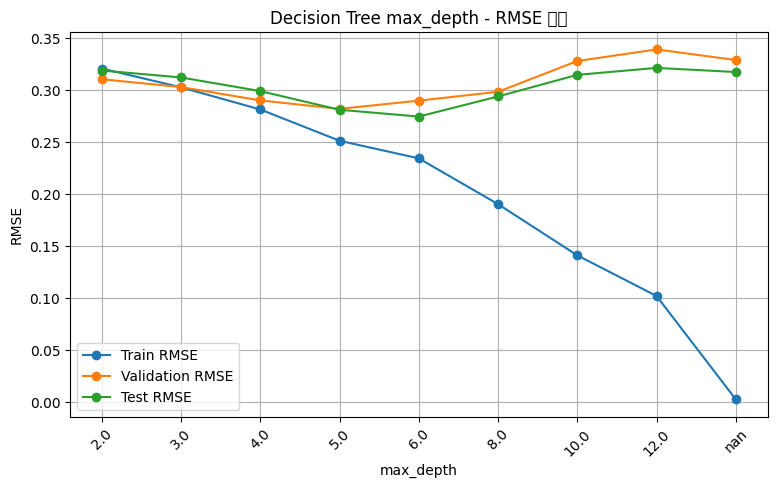

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


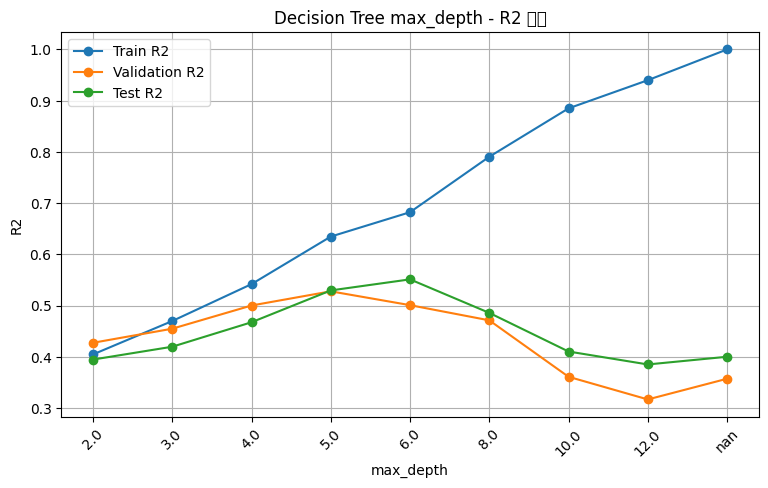

In [ ]:
dt_max_depth_values = [2, 3, 4, 5, 6, 8, 10, 12, None]

dt_max_depth_result = run_dt_sweep(
    param_name="max_depth",
    values=dt_max_depth_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None
    }
)

display(dt_max_depth_result)
show_best_by_validation(dt_max_depth_result, "DT max_depth")
plot_hparam_result(dt_max_depth_result, "max_depth", "Decision Tree max_depth")

,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,min_samples_leaf,1,6,2,None,0.036719,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114
1,dt,min_samples_leaf,2,6,2,None,0.020783,0.248551,0.281843,0.275057,0.641691,0.526997,0.548453
2,dt,min_samples_leaf,4,6,2,None,0.039834,0.251369,0.283186,0.282914,0.633520,0.522479,0.522288
3,dt,min_samples_leaf,8,6,2,None,0.020037,0.254964,0.276494,0.278117,0.622963,0.544783,0.538349
4,dt,min_samples_leaf,16,6,2,None,0.020762,0.259242,0.276755,0.275817,0.610204,0.543923,0.545953
5,dt,min_samples_leaf,32,6,2,None,0.018706,0.266769,0.281597,0.276135,0.587242,0.527824,0.544905


[DT min_samples_leaf] Validation RMSE 기준 best


,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,dt,min_samples_leaf,8,6,2,None,0.020037,0.254964,0.276494,0.278117,0.622963,0.544783,0.538349


[DT min_samples_leaf] Validation R2 기준 best


,model,changed_param,min_samples_leaf,max_depth,min_samples_split,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
3,dt,min_samples_leaf,8,6,2,None,0.020037,0.254964,0.276494,0.278117,0.622963,0.544783,0.538349


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


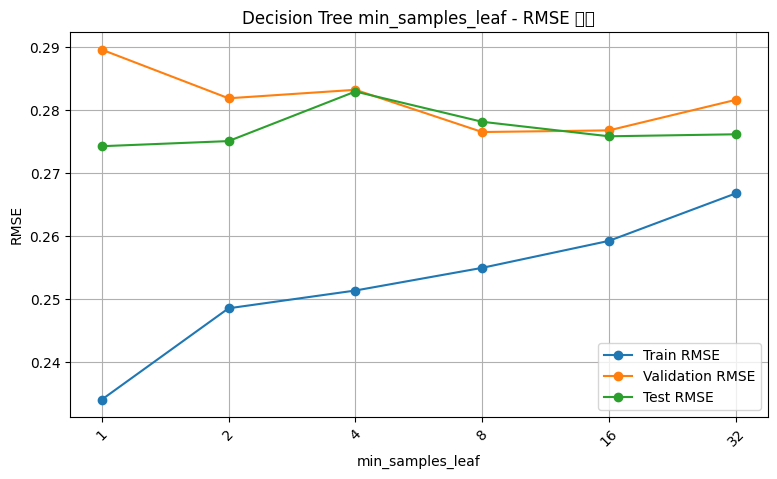

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


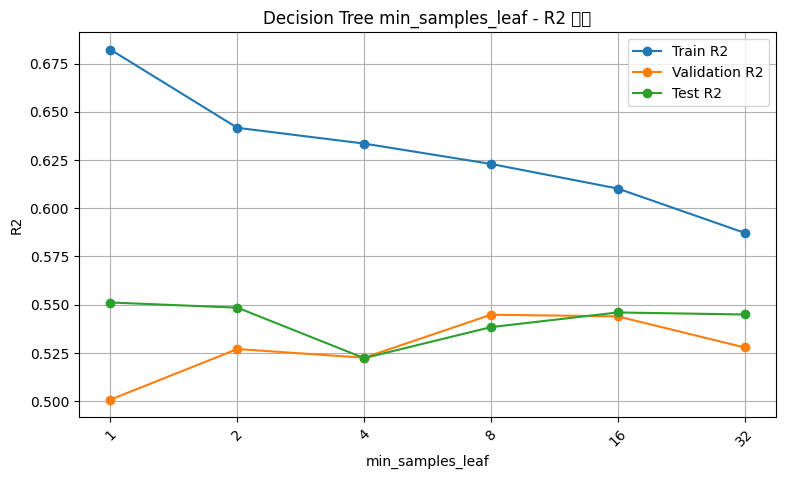

In [ ]:
dt_min_samples_leaf_values = [1, 2, 4, 8, 16, 32]

dt_min_leaf_result = run_dt_sweep(
    param_name="min_samples_leaf",
    values=dt_min_samples_leaf_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None
    }
)

display(dt_min_leaf_result)
show_best_by_validation(dt_min_leaf_result, "DT min_samples_leaf")
plot_hparam_result(dt_min_leaf_result, "min_samples_leaf", "Decision Tree min_samples_leaf")

,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,min_samples_split,2,6,1,None,0.183185,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114
1,dt,min_samples_split,4,6,1,None,0.105256,0.234213,0.290496,0.274183,0.681839,0.497509,0.551317
2,dt,min_samples_split,8,6,1,None,0.107441,0.234812,0.290496,0.273485,0.680208,0.497509,0.553599
3,dt,min_samples_split,16,6,1,None,0.050777,0.234812,0.290496,0.273485,0.680208,0.497509,0.553599
4,dt,min_samples_split,32,6,1,None,0.126079,0.235144,0.287871,0.274537,0.679304,0.506549,0.550160
5,dt,min_samples_split,64,6,1,None,0.062958,0.241180,0.291348,0.276818,0.662627,0.494556,0.542654


[DT min_samples_split] Validation RMSE 기준 best


,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,min_samples_split,32,6,1,None,0.126079,0.235144,0.287871,0.274537,0.679304,0.506549,0.55016


[DT min_samples_split] Validation R2 기준 best


,model,changed_param,min_samples_split,max_depth,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,min_samples_split,32,6,1,None,0.126079,0.235144,0.287871,0.274537,0.679304,0.506549,0.55016


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


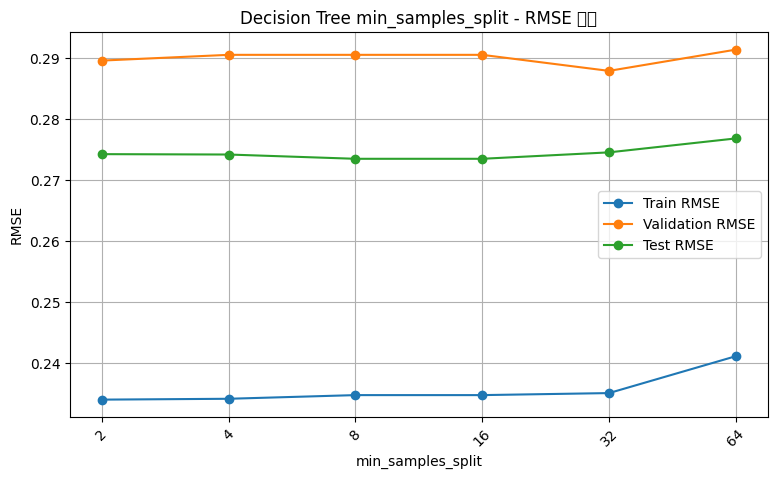

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


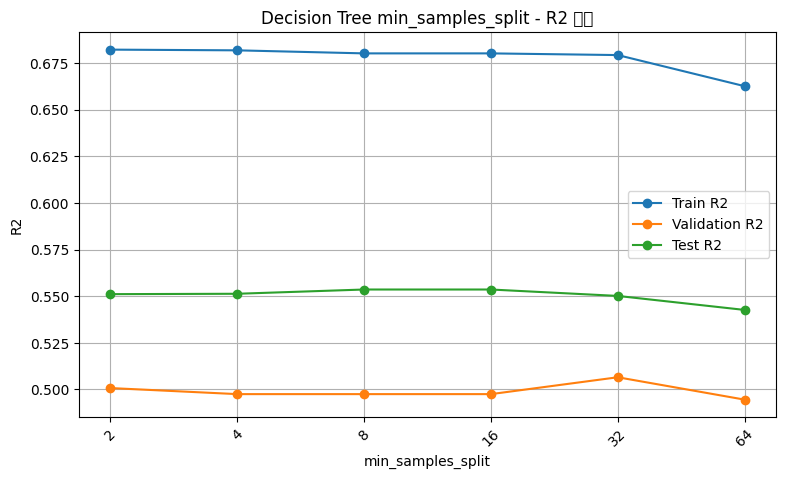

In [ ]:
dt_min_samples_split_values = [2, 4, 8, 16, 32, 64]

dt_min_split_result = run_dt_sweep(
    param_name="min_samples_split",
    values=dt_min_samples_split_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None
    }
)

display(dt_min_split_result)
show_best_by_validation(dt_min_split_result, "DT min_samples_split")
plot_hparam_result(dt_min_split_result, "min_samples_split", "Decision Tree min_samples_split")

,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_features,None,6,2,1,0.023318,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114
1,dt,max_features,sqrt,6,2,1,0.009351,0.262672,0.323458,0.304735,0.599821,0.377004,0.445755
2,dt,max_features,log2,6,2,1,0.007109,0.262672,0.323458,0.304735,0.599821,0.377004,0.445755
3,dt,max_features,0.3,6,2,1,0.010809,0.277460,0.279851,0.297360,0.553496,0.533660,0.472256
4,dt,max_features,0.5,6,2,1,0.034812,0.257289,0.276405,0.279972,0.616057,0.545075,0.532172
5,dt,max_features,0.7,6,2,1,0.021376,0.239919,0.278411,0.288473,0.666147,0.538447,0.503329
6,dt,max_features,1.0,6,2,1,0.027080,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114


[DT max_features] Validation RMSE 기준 best


,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,max_features,0.5,6,2,1,0.034812,0.257289,0.276405,0.279972,0.616057,0.545075,0.532172


[DT max_features] Validation R2 기준 best


,model,changed_param,max_features,max_depth,min_samples_split,min_samples_leaf,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,dt,max_features,0.5,6,2,1,0.034812,0.257289,0.276405,0.279972,0.616057,0.545075,0.532172


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


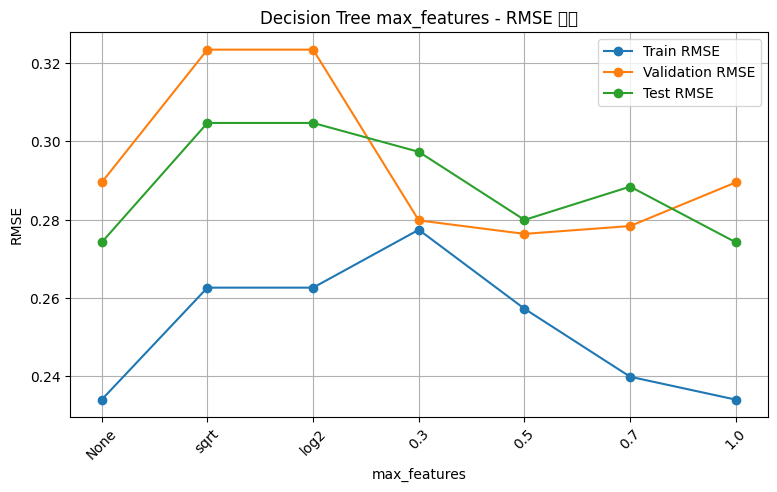

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


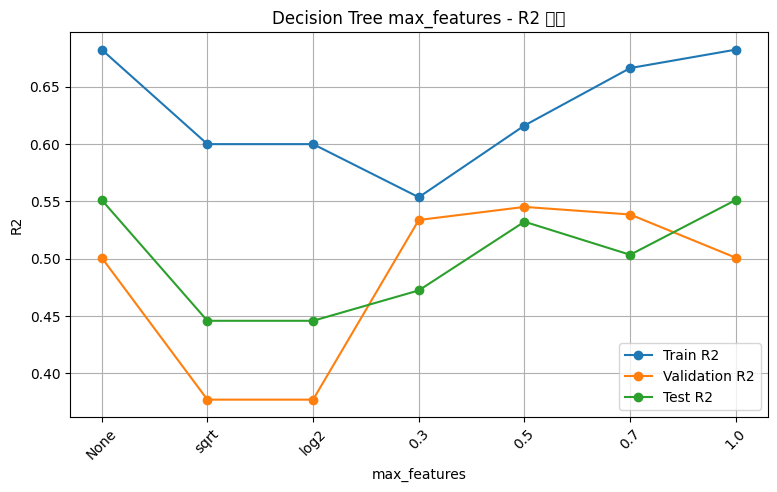

In [ ]:
dt_max_features_values = [None, "sqrt", "log2", 0.3, 0.5, 0.7, 1.0]

dt_max_features_result = run_dt_sweep(
    param_name="max_features",
    values=dt_max_features_values,
    base_params={
        "max_depth": 6,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": None
    }
)

display(dt_max_features_result)
show_best_by_validation(dt_max_features_result, "DT max_features")
plot_hparam_result(dt_max_features_result, "max_features", "Decision Tree max_features")

In [ ]:
dt_all_results = pd.concat(
    [
        dt_max_depth_result,
        dt_min_leaf_result,
        dt_min_split_result,
        dt_max_features_result
    ],
    ignore_index=True
)

display(dt_all_results)

print("DT 전체 실험 중 Validation RMSE 기준 상위 10개")
display(dt_all_results.sort_values("val_rmse").head(10))

print("DT 전체 실험 중 Validation R2 기준 상위 10개")
display(dt_all_results.sort_values("val_r2", ascending=False).head(10))

,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,dt,max_depth,2.0,2,1,None,0.010270,0.320407,0.310128,0.318500,0.404570,0.427297,0.394553
1,dt,max_depth,3.0,2,1,None,0.013499,0.302357,0.302591,0.311840,0.469768,0.454793,0.419608
2,dt,max_depth,4.0,2,1,None,0.014339,0.281068,0.289752,0.298734,0.541808,0.500079,0.467368
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.634610,0.527744,0.529514
4,dt,max_depth,6.0,2,1,None,0.020674,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114
5,dt,max_depth,8.0,2,1,None,0.029596,0.190065,0.298027,0.293556,0.790478,0.471116,0.485673
6,dt,max_depth,10.0,2,1,None,0.040617,0.140842,0.327613,0.314346,0.884949,0.360898,0.410244
7,dt,max_depth,12.0,2,1,None,0.064343,0.101767,0.338752,0.321003,0.939932,0.316697,0.385000
8,dt,max_depth,NaN,2,1,None,0.055845,0.002365,0.328583,0.317057,0.999968,0.357109,0.400025
9,dt,min_samples_leaf,6.0,2,1,None,0.036719,0.234073,0.289555,0.274245,0.682219,0.500760,0.551114


DT 전체 실험 중 Validation RMSE 기준 상위 10개


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
25,dt,max_features,6.0,2,1,0.5,0.034812,0.257289,0.276405,0.279972,0.616057,0.545075,0.532172
12,dt,min_samples_leaf,6.0,2,8,None,0.020037,0.254964,0.276494,0.278117,0.622963,0.544783,0.538349
13,dt,min_samples_leaf,6.0,2,16,None,0.020762,0.259242,0.276755,0.275817,0.610204,0.543923,0.545953
26,dt,max_features,6.0,2,1,0.7,0.021376,0.239919,0.278411,0.288473,0.666147,0.538447,0.503329
24,dt,max_features,6.0,2,1,0.3,0.010809,0.277460,0.279851,0.297360,0.553496,0.533660,0.472256
14,dt,min_samples_leaf,6.0,2,32,None,0.018706,0.266769,0.281597,0.276135,0.587242,0.527824,0.544905
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.634610,0.527744,0.529514
10,dt,min_samples_leaf,6.0,2,2,None,0.020783,0.248551,0.281843,0.275057,0.641691,0.526997,0.548453
11,dt,min_samples_leaf,6.0,2,4,None,0.039834,0.251369,0.283186,0.282914,0.633520,0.522479,0.522288
19,dt,min_samples_split,6.0,32,1,None,0.126079,0.235144,0.287871,0.274537,0.679304,0.506549,0.550160


DT 전체 실험 중 Validation R2 기준 상위 10개


,model,changed_param,max_depth,min_samples_split,min_samples_leaf,max_features,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
25,dt,max_features,6.0,2,1,0.5,0.034812,0.257289,0.276405,0.279972,0.616057,0.545075,0.532172
12,dt,min_samples_leaf,6.0,2,8,None,0.020037,0.254964,0.276494,0.278117,0.622963,0.544783,0.538349
13,dt,min_samples_leaf,6.0,2,16,None,0.020762,0.259242,0.276755,0.275817,0.610204,0.543923,0.545953
26,dt,max_features,6.0,2,1,0.7,0.021376,0.239919,0.278411,0.288473,0.666147,0.538447,0.503329
24,dt,max_features,6.0,2,1,0.3,0.010809,0.277460,0.279851,0.297360,0.553496,0.533660,0.472256
14,dt,min_samples_leaf,6.0,2,32,None,0.018706,0.266769,0.281597,0.276135,0.587242,0.527824,0.544905
3,dt,max_depth,5.0,2,1,None,0.018928,0.250995,0.281621,0.280766,0.634610,0.527744,0.529514
10,dt,min_samples_leaf,6.0,2,2,None,0.020783,0.248551,0.281843,0.275057,0.641691,0.526997,0.548453
11,dt,min_samples_leaf,6.0,2,4,None,0.039834,0.251369,0.283186,0.282914,0.633520,0.522479,0.522288
19,dt,min_samples_split,6.0,32,1,None,0.126079,0.235144,0.287871,0.274537,0.679304,0.506549,0.550160


# MLP

In [ ]:
def run_mlp_sweep(param_name, values, base_model_params=None, base_train_params=None):
    if base_model_params is None:
        base_model_params = {
            "hidden_dims": [32, 32],
            "dropout": 0.2,
            "activation": nn.ReLU,
            "use_batch_norm": False
        }

    if base_train_params is None:
        base_train_params = {
            "epochs": 100,
            "lr": 1e-3,
            "batch_size": 64,
            "verbose": False
        }

    model_param_names = {"hidden_dims", "dropout", "activation", "use_batch_norm"}
    train_param_names = {"epochs", "lr", "batch_size", "verbose"}

    results = []

    for value in values:
        model_params = copy.deepcopy(base_model_params)
        train_params = copy.deepcopy(base_train_params)

        if param_name in model_param_names:
            model_params[param_name] = value
        elif param_name in train_param_names:
            train_params[param_name] = value
        else:
            raise ValueError(f"지원하지 않는 MLP 파라미터입니다: {param_name}")

        set_seed(SEED)

        config = MLPConfig(
            model="mlp",
            input_dim=X_train_mlp.shape[1],
            hidden_dims=model_params["hidden_dims"],
            output_dim=1,
            dropout=model_params["dropout"],
            activation=model_params["activation"],
            use_batch_norm=model_params["use_batch_norm"]
        )

        model = MLP(config)

        train_config = TrainConfig(
            X=X_train_mlp,
            y=y_train,
            epochs=train_params["epochs"],
            lr=train_params["lr"],
            batch_size=train_params["batch_size"],
            verbose=train_params["verbose"]
        )

        start_time = time.time()
        model.fit(train_config)
        elapsed = time.time() - start_time

        row = {
            "model": "mlp",
            "changed_param": param_name,
            param_name: value,
            "hidden_dims": str(model_params["hidden_dims"]),
            "dropout": model_params["dropout"],
            "activation": model_params["activation"].__name__,
            "use_batch_norm": model_params["use_batch_norm"],
            "epochs": train_params["epochs"],
            "lr": train_params["lr"],
            "batch_size": train_params["batch_size"],
            "train_time_sec": elapsed
        }

        row = add_eval_results(
            row,
            model,
            X_train_mlp, y_train,
            X_val_mlp, y_val,
            X_test_mlp, y_test
        )

        results.append(row)

    return pd.DataFrame(results)

,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,hidden_dims,[16],0.2,ReLU,False,100,0.001,64,20.406317,0.344276,0.335032,0.352343,0.312551,0.331626,0.259050
1,mlp,hidden_dims,[32],0.2,ReLU,False,100,0.001,64,6.584284,0.318381,0.298418,0.321580,0.412079,0.469729,0.382785
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.001,64,7.960849,0.292549,0.278800,0.307122,0.503611,0.537157,0.437037
3,mlp,hidden_dims,"[32, 32]",0.2,ReLU,False,100,0.001,64,7.271172,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.001,64,9.556101,0.323182,0.312803,0.331269,0.394213,0.417373,0.345033
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64,7.917564,0.293065,0.281153,0.302149,0.501859,0.529310,0.455121
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.001,64,10.180936,0.295332,0.290159,0.304513,0.494121,0.498675,0.446561
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038


[MLP hidden_dims] Validation RMSE 기준 best


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038


[MLP hidden_dims] Validation R2 기준 best


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


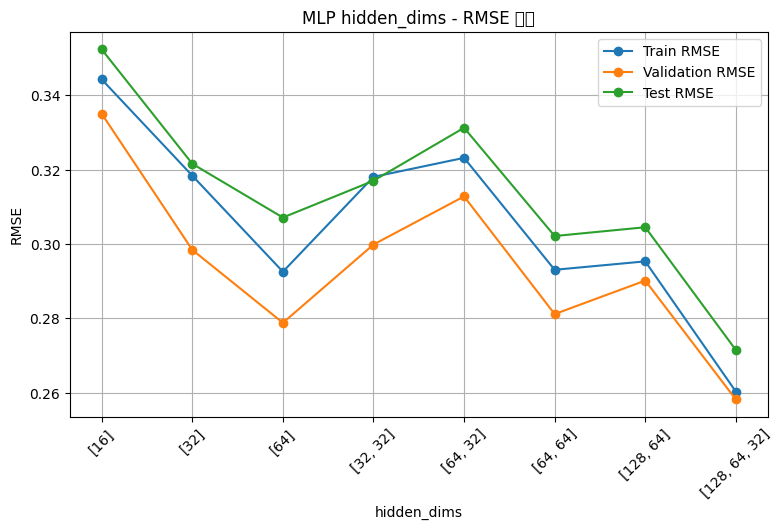

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


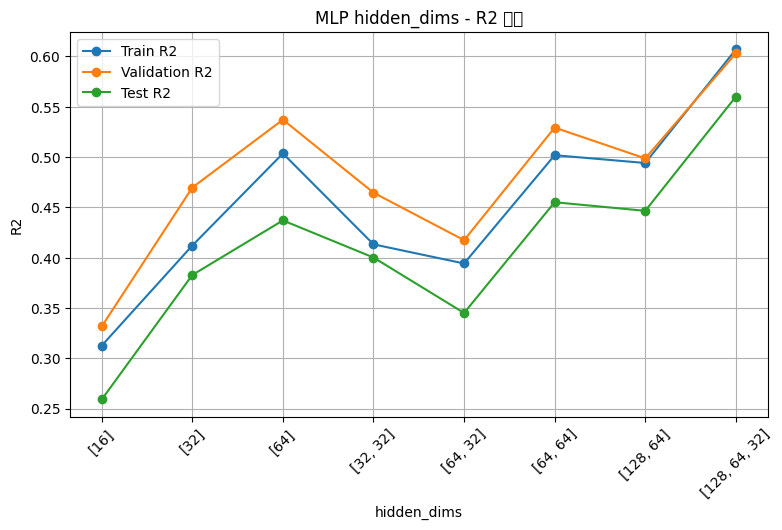

In [ ]:
mlp_hidden_dims_values = [
    [16],
    [32],
    [64],
    [32, 32],
    [64, 32],
    [64, 64],
    [128, 64],
    [128, 64, 32]
]

mlp_hidden_result = run_mlp_sweep(
    param_name="hidden_dims",
    values=mlp_hidden_dims_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_hidden_result)
show_best_by_validation(mlp_hidden_result, "MLP hidden_dims")
plot_hparam_result(mlp_hidden_result, "hidden_dims", "MLP hidden_dims")

,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,dropout,0.0,"[32, 32]",ReLU,False,100,0.001,64,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738
1,mlp,dropout,0.1,"[32, 32]",ReLU,False,100,0.001,64,8.049581,0.318155,0.303833,0.326958,0.412913,0.450311,0.361971
2,mlp,dropout,0.2,"[32, 32]",ReLU,False,100,0.001,64,22.248002,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
3,mlp,dropout,0.3,"[32, 32]",ReLU,False,100,0.001,64,12.963452,0.340734,0.322591,0.340627,0.326624,0.380341,0.307505
4,mlp,dropout,0.5,"[32, 32]",ReLU,False,100,0.001,64,12.195501,0.372341,0.357348,0.372429,0.195903,0.239621,0.172161


[MLP dropout] Validation RMSE 기준 best


,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,dropout,0.0,"[32, 32]",ReLU,False,100,0.001,64,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738


[MLP dropout] Validation R2 기준 best


,model,changed_param,dropout,hidden_dims,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,dropout,0.0,"[32, 32]",ReLU,False,100,0.001,64,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


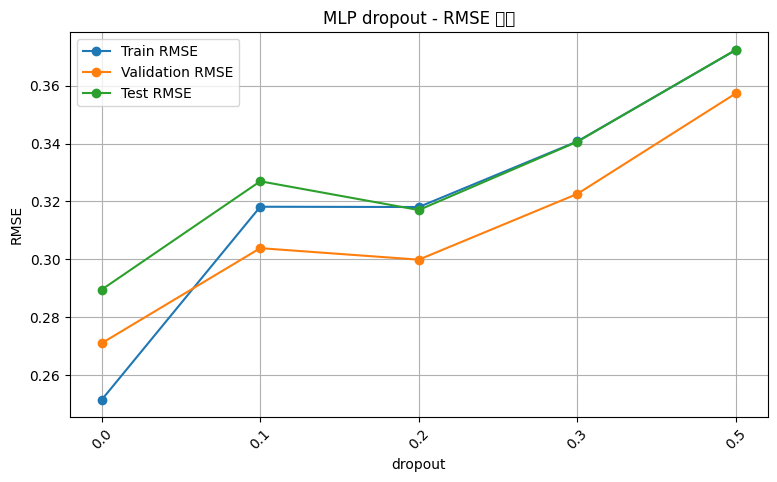

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


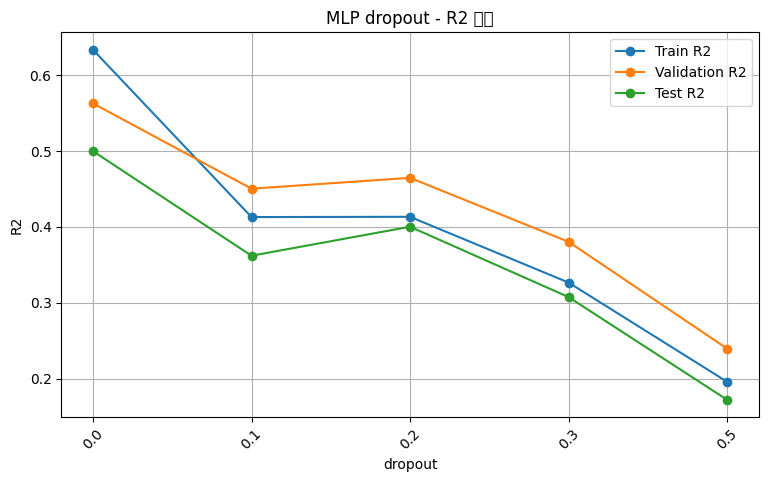

In [ ]:
mlp_dropout_values = [0.0, 0.1, 0.2, 0.3, 0.5]

mlp_dropout_result = run_mlp_sweep(
    param_name="dropout",
    values=mlp_dropout_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_dropout_result)
show_best_by_validation(mlp_dropout_result, "MLP dropout")
plot_hparam_result(mlp_dropout_result, "dropout", "MLP dropout")

,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,lr,0.0001,"[32, 32]",0.2,ReLU,False,100,64,10.493538,0.656818,0.640416,0.645936,-1.502164,-1.442154,-1.490218
1,mlp,lr,0.0003,"[32, 32]",0.2,ReLU,False,100,64,8.034351,0.376476,0.362208,0.376891,0.177945,0.218795,0.152208
2,mlp,lr,0.0010,"[32, 32]",0.2,ReLU,False,100,64,8.500220,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
3,mlp,lr,0.0030,"[32, 32]",0.2,ReLU,False,100,64,7.162817,0.286647,0.266941,0.293388,0.523435,0.575693,0.486262
4,mlp,lr,0.0100,"[32, 32]",0.2,ReLU,False,100,64,8.762252,0.247518,0.243463,0.264879,0.644664,0.647048,0.581252


[MLP learning rate] Validation RMSE 기준 best


,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,mlp,lr,0.01,"[32, 32]",0.2,ReLU,False,100,64,8.762252,0.247518,0.243463,0.264879,0.644664,0.647048,0.581252


[MLP learning rate] Validation R2 기준 best


,model,changed_param,lr,hidden_dims,dropout,activation,use_batch_norm,epochs,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
4,mlp,lr,0.01,"[32, 32]",0.2,ReLU,False,100,64,8.762252,0.247518,0.243463,0.264879,0.644664,0.647048,0.581252


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


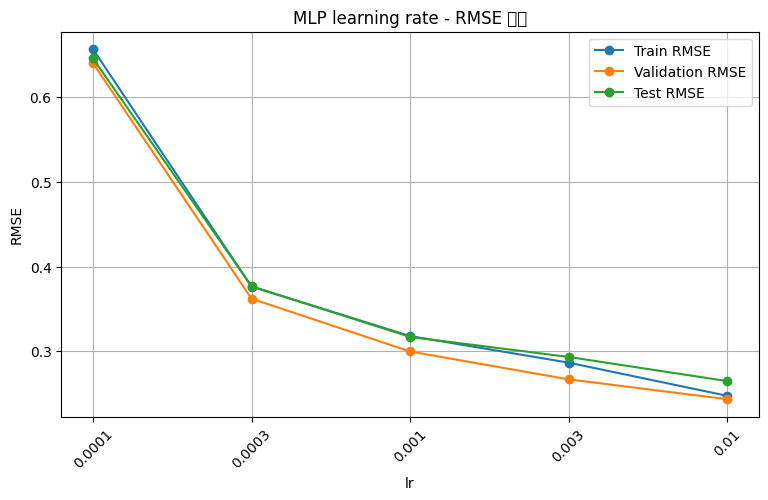

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


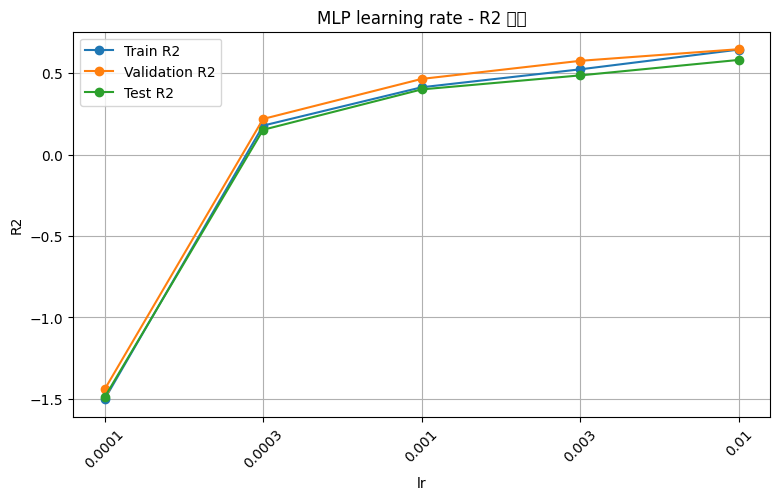

In [ ]:
mlp_lr_values = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]

mlp_lr_result = run_mlp_sweep(
    param_name="lr",
    values=mlp_lr_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_lr_result)
show_best_by_validation(mlp_lr_result, "MLP learning rate")
plot_hparam_result(mlp_lr_result, "lr", "MLP learning rate")

,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,22.685874,0.257675,0.246967,0.266967,0.614903,0.636817,0.574624
1,mlp,batch_size,32.0,"[32, 32]",0.2,ReLU,False,100,0.001,14.720367,0.299183,0.278800,0.300771,0.480843,0.537155,0.460078
2,mlp,batch_size,64.0,"[32, 32]",0.2,ReLU,False,100,0.001,8.603760,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
3,mlp,batch_size,128.0,"[32, 32]",0.2,ReLU,False,100,0.001,4.890233,0.342604,0.326342,0.345667,0.319212,0.365848,0.286860
4,mlp,batch_size,256.0,"[32, 32]",0.2,ReLU,False,100,0.001,5.415749,0.377754,0.361512,0.377428,0.172355,0.221796,0.149790
5,mlp,batch_size,NaN,"[32, 32]",0.2,ReLU,False,100,0.001,3.504254,1.365279,1.322925,1.375287,-9.811066,-9.421227,-10.288718


[MLP batch_size] Validation RMSE 기준 best


,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,22.685874,0.257675,0.246967,0.266967,0.614903,0.636817,0.574624


[MLP batch_size] Validation R2 기준 best


,model,changed_param,batch_size,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,batch_size,16.0,"[32, 32]",0.2,ReLU,False,100,0.001,22.685874,0.257675,0.246967,0.266967,0.614903,0.636817,0.574624


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


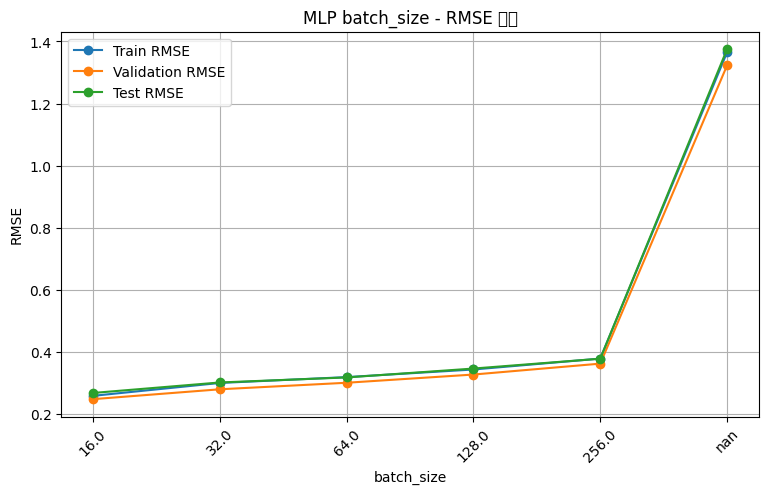

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


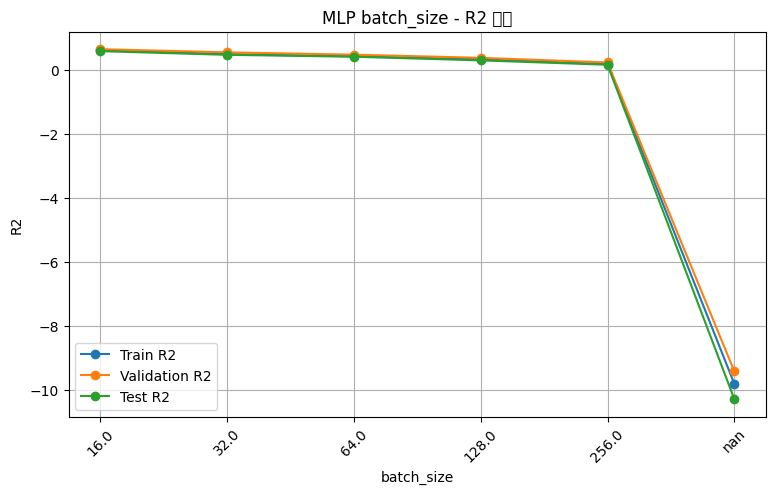

In [ ]:
mlp_batch_size_values = [16, 32, 64, 128, 256, None]

mlp_batch_result = run_mlp_sweep(
    param_name="batch_size",
    values=mlp_batch_size_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_batch_result)
show_best_by_validation(mlp_batch_result, "MLP batch_size")
plot_hparam_result(mlp_batch_result, "batch_size", "MLP batch_size")

,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,epochs,10,"[32, 32]",0.2,ReLU,False,0.001,64,0.699839,0.709817,0.694732,0.695212,-1.922258,-1.873978,-1.884647
1,mlp,epochs,30,"[32, 32]",0.2,ReLU,False,0.001,64,2.081254,0.383913,0.373177,0.380238,0.145146,0.170763,0.137083
2,mlp,epochs,50,"[32, 32]",0.2,ReLU,False,0.001,64,5.023052,0.345395,0.329541,0.347604,0.308076,0.353354,0.278849
3,mlp,epochs,100,"[32, 32]",0.2,ReLU,False,0.001,64,6.731874,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
4,mlp,epochs,150,"[32, 32]",0.2,ReLU,False,0.001,64,12.240643,0.298567,0.277948,0.300640,0.482977,0.539980,0.460549
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,15.857144,0.281586,0.262430,0.284142,0.540117,0.589915,0.518130


[MLP epochs] Validation RMSE 기준 best


,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,15.857144,0.281586,0.26243,0.284142,0.540117,0.589915,0.51813


[MLP epochs] Validation R2 기준 best


,model,changed_param,epochs,hidden_dims,dropout,activation,use_batch_norm,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
5,mlp,epochs,200,"[32, 32]",0.2,ReLU,False,0.001,64,15.857144,0.281586,0.26243,0.284142,0.540117,0.589915,0.51813


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


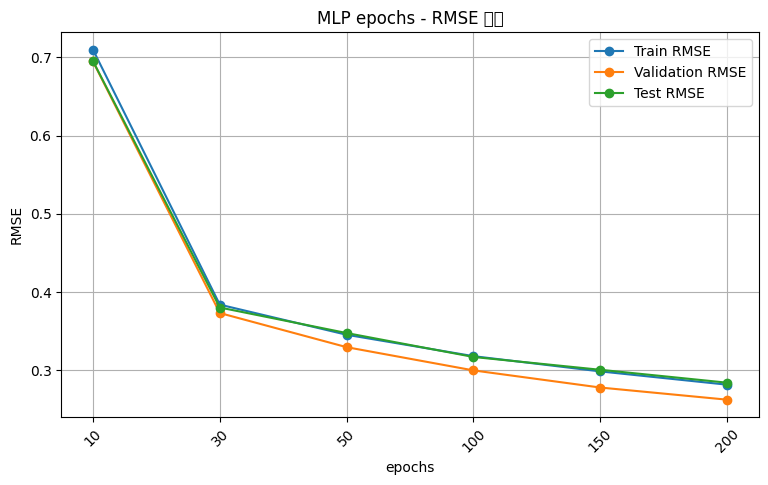

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


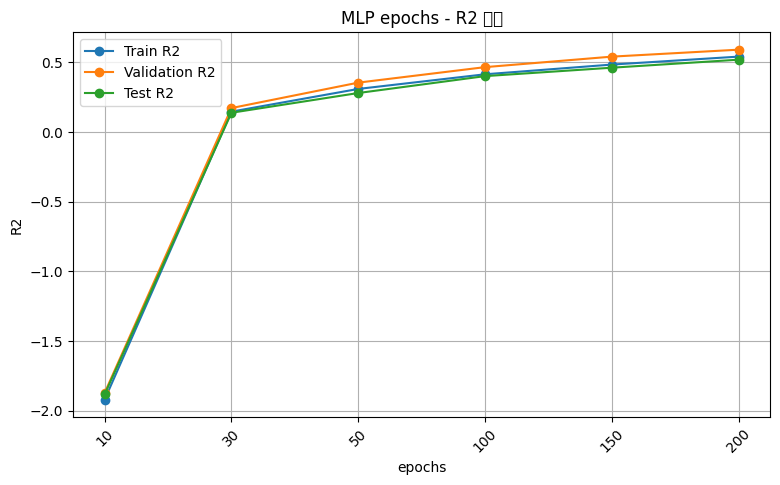

In [ ]:
mlp_epochs_values = [10, 30, 50, 100, 150, 200]

mlp_epochs_result = run_mlp_sweep(
    param_name="epochs",
    values=mlp_epochs_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_epochs_result)
show_best_by_validation(mlp_epochs_result, "MLP epochs")
plot_hparam_result(mlp_epochs_result, "epochs", "MLP epochs")

,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,activation,ReLU,"[32, 32]",0.2,False,100,0.001,64,8.696234,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
1,mlp,activation,Tanh,"[32, 32]",0.2,False,100,0.001,64,7.119179,0.337253,0.321825,0.338648,0.340313,0.383280,0.315527
2,mlp,activation,LeakyReLU,"[32, 32]",0.2,False,100,0.001,64,8.582763,0.324577,0.307414,0.325510,0.388972,0.437276,0.367607
3,mlp,activation,ELU,"[32, 32]",0.2,False,100,0.001,64,7.119192,0.322594,0.303853,0.324924,0.396414,0.450238,0.369884


[MLP activation] Validation RMSE 기준 best


,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,activation,ReLU,"[32, 32]",0.2,False,100,0.001,64,8.696234,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157


[MLP activation] Validation R2 기준 best


,model,changed_param,activation,hidden_dims,dropout,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,activation,ReLU,"[32, 32]",0.2,False,100,0.001,64,8.696234,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


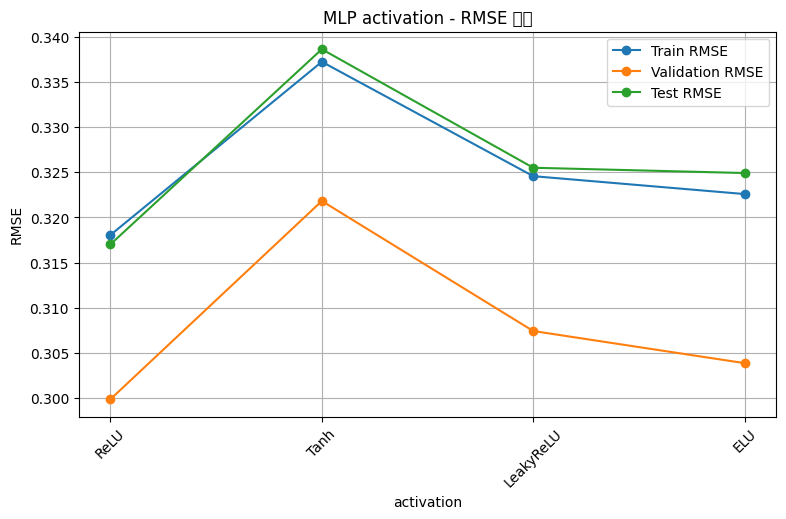

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


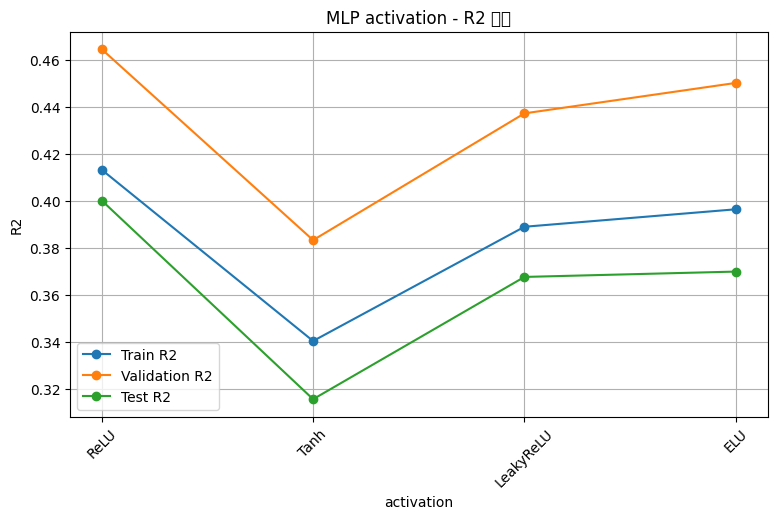

In [ ]:
mlp_activation_values = [nn.ReLU, nn.Tanh, nn.LeakyReLU, nn.ELU]

mlp_activation_result = run_mlp_sweep(
    param_name="activation",
    values=mlp_activation_values,
    base_model_params={
        "hidden_dims": [32, 32],
        "dropout": 0.2,
        "activation": nn.ReLU,
        "use_batch_norm": False
    },
    base_train_params={
        "epochs": 100,
        "lr": 1e-3,
        "batch_size": 64,
        "verbose": False
    }
)

display(mlp_activation_result)
show_best_by_validation(mlp_activation_result, "MLP activation")
plot_hparam_result(mlp_activation_result, "activation", "MLP activation")

In [ ]:
mlp_all_results = pd.concat(
    [
        mlp_hidden_result,
        mlp_dropout_result,
        mlp_lr_result,
        mlp_batch_result,
        mlp_epochs_result,
        mlp_activation_result
    ],
    ignore_index=True
)

display(mlp_all_results)

print("MLP 전체 실험 중 Validation RMSE 기준 상위 10개")
display(mlp_all_results.sort_values("val_rmse").head(10))

print("MLP 전체 실험 중 Validation R2 기준 상위 10개")
display(mlp_all_results.sort_values("val_r2", ascending=False).head(10))

,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,mlp,hidden_dims,[16],0.2,ReLU,False,100,0.0010,64.0,20.406317,0.344276,0.335032,0.352343,0.312551,0.331626,0.259050
1,mlp,hidden_dims,[32],0.2,ReLU,False,100,0.0010,64.0,6.584284,0.318381,0.298418,0.321580,0.412079,0.469729,0.382785
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.0010,64.0,7.960849,0.292549,0.278800,0.307122,0.503611,0.537157,0.437037
3,mlp,hidden_dims,"[32, 32]",0.2,ReLU,False,100,0.0010,64.0,7.271172,0.318062,0.299857,0.317022,0.413256,0.464602,0.400157
4,mlp,hidden_dims,"[64, 32]",0.2,ReLU,False,100,0.0010,64.0,9.556101,0.323182,0.312803,0.331269,0.394213,0.417373,0.345033
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.0010,64.0,7.917564,0.293065,0.281153,0.302149,0.501859,0.529310,0.455121
6,mlp,hidden_dims,"[128, 64]",0.2,ReLU,False,100,0.0010,64.0,10.180936,0.295332,0.290159,0.304513,0.494121,0.498675,0.446561
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.0010,64.0,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038
8,mlp,dropout,"[32, 32]",0.0,ReLU,False,100,0.0010,64.0,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738
9,mlp,dropout,"[32, 32]",0.1,ReLU,False,100,0.0010,64.0,8.049581,0.318155,0.303833,0.326958,0.412913,0.450311,0.361971


MLP 전체 실험 중 Validation RMSE 기준 상위 10개


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
17,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.010,64.0,8.762252,0.247518,0.243463,0.264879,0.644664,0.647048,0.581252
18,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,16.0,22.685874,0.257675,0.246967,0.266967,0.614903,0.636817,0.574624
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64.0,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038
29,mlp,epochs,"[32, 32]",0.2,ReLU,False,200,0.001,64.0,15.857144,0.281586,0.262430,0.284142,0.540117,0.589915,0.518130
16,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.003,64.0,7.162817,0.286647,0.266941,0.293388,0.523435,0.575693,0.486262
8,mlp,dropout,"[32, 32]",0.0,ReLU,False,100,0.001,64.0,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738
28,mlp,epochs,"[32, 32]",0.2,ReLU,False,150,0.001,64.0,12.240643,0.298567,0.277948,0.300640,0.482977,0.539980,0.460549
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.001,64.0,7.960849,0.292549,0.278800,0.307122,0.503611,0.537157,0.437037
19,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,32.0,14.720367,0.299183,0.278800,0.300771,0.480843,0.537155,0.460078
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64.0,7.917564,0.293065,0.281153,0.302149,0.501859,0.529310,0.455121


MLP 전체 실험 중 Validation R2 기준 상위 10개


,model,changed_param,hidden_dims,dropout,activation,use_batch_norm,epochs,lr,batch_size,train_time_sec,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
17,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.010,64.0,8.762252,0.247518,0.243463,0.264879,0.644664,0.647048,0.581252
18,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,16.0,22.685874,0.257675,0.246967,0.266967,0.614903,0.636817,0.574624
7,mlp,hidden_dims,"[128, 64, 32]",0.2,ReLU,False,100,0.001,64.0,11.319041,0.260307,0.258181,0.271505,0.606994,0.603084,0.560038
29,mlp,epochs,"[32, 32]",0.2,ReLU,False,200,0.001,64.0,15.857144,0.281586,0.262430,0.284142,0.540117,0.589915,0.518130
16,mlp,lr,"[32, 32]",0.2,ReLU,False,100,0.003,64.0,7.162817,0.286647,0.266941,0.293388,0.523435,0.575693,0.486262
8,mlp,dropout,"[32, 32]",0.0,ReLU,False,100,0.001,64.0,7.930632,0.251418,0.270986,0.289514,0.633379,0.562739,0.499738
28,mlp,epochs,"[32, 32]",0.2,ReLU,False,150,0.001,64.0,12.240643,0.298567,0.277948,0.300640,0.482977,0.539980,0.460549
2,mlp,hidden_dims,[64],0.2,ReLU,False,100,0.001,64.0,7.960849,0.292549,0.278800,0.307122,0.503611,0.537157,0.437037
19,mlp,batch_size,"[32, 32]",0.2,ReLU,False,100,0.001,32.0,14.720367,0.299183,0.278800,0.300771,0.480843,0.537155,0.460078
5,mlp,hidden_dims,"[64, 64]",0.2,ReLU,False,100,0.001,64.0,7.917564,0.293065,0.281153,0.302149,0.501859,0.529310,0.455121


DT vs MLP 최종 비교 그래프

In [ ]:
best_dt = dt_all_results.loc[dt_all_results["val_rmse"].idxmin()].copy()
best_mlp = mlp_all_results.loc[mlp_all_results["val_rmse"].idxmin()].copy()

comparison_df = pd.DataFrame([
    {
        "model": "Decision Tree",
        "best_changed_param": best_dt["changed_param"],
        "val_rmse": best_dt["val_rmse"],
        "test_rmse": best_dt["test_rmse"],
        "val_r2": best_dt["val_r2"],
        "test_r2": best_dt["test_r2"]
    },
    {
        "model": "MLP",
        "best_changed_param": best_mlp["changed_param"],
        "val_rmse": best_mlp["val_rmse"],
        "test_rmse": best_mlp["test_rmse"],
        "val_r2": best_mlp["val_r2"],
        "test_r2": best_mlp["test_r2"]
    }
])

display(comparison_df)

,model,best_changed_param,val_rmse,test_rmse,val_r2,test_r2
0,Decision Tree,max_features,0.276405,0.279972,0.545075,0.532172
1,MLP,lr,0.243463,0.264879,0.647048,0.581252


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


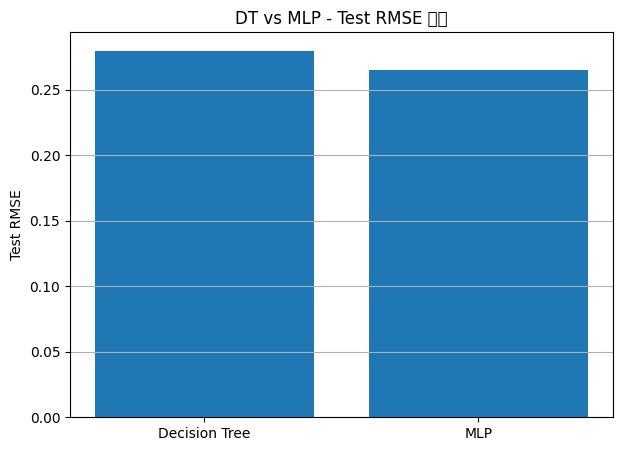

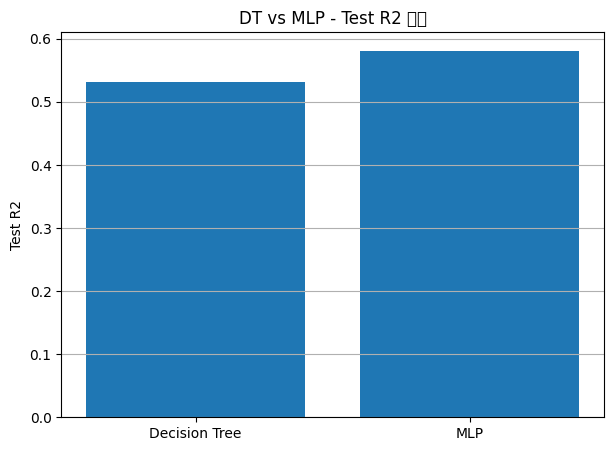

In [ ]:
# RMSE 비교
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["test_rmse"])
plt.ylabel("Test RMSE")
plt.title("DT vs MLP - Test RMSE 비교")
plt.grid(axis="y")
plt.show()

# R2 비교
plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["test_r2"])
plt.ylabel("Test R2")
plt.title("DT vs MLP - Test R2 비교")
plt.grid(axis="y")
plt.show()